<a href="https://colab.research.google.com/github/Ivanrenzmond-solidos/CPE310-IE22S1/blob/main/GROUP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Netflix Dataset Analysis**

**COURSE NAME:** FUNDAMENTALS OF DATA SCIENCE

**COURSE CODE: **CPE 310



**MEMBERS:**

IVAN RENZMOND CASTULO

CEDRICK GUILLANG

JOHN RHAVEN MEDINA

RAINIEL ESTACIO

SHERWIN DARREL TRIBIANO



**SECTION:** IE22S1

**DATE SUBMITTED:** 4/23/2026

**INSTRUCTOR:** ENGR, JIMLORD QUEJANO

# **1. Data Loading & Overview**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/netflix_titles (1).csv')

df.shape
df.head()
df.tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# **2. Data Cleaning**

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**Handling**:

In [ ]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

df.dropna(subset=['date_added'], inplace=True)

/tmp/ipykernel_16711/3309515911.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_16711/3309515911.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

# **3. Data Types & Conversion**

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# **4. Univariate Analysis**

In [ ]:
df['type'].value_counts()
df['rating'].value_counts().head(5)
df['release_year'].value_counts().idxmax()

np.int64(2018)

# **5. Duration & Seasons**

In [ ]:
# Separate duration
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

movies = df[df['type'] == 'Movie']
tv = df[df['type'] == 'TV Show']

avg_movie_length = movies['duration_num'].mean()
avg_seasons = tv['duration_num'].mean()

print(avg_movie_length, avg_seasons)

99.57718668407311 1.7513128282070518


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_16711/744513145.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


# **6. Genre Analysis**

In [ ]:
df_exploded = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

genre_avg_year = (
    df_exploded
    .groupby('listed_in')['release_year']
    .mean()
    .sort_values(ascending=False)
)

genre_avg_year.head()

,release_year
listed_in,
TV Mysteries,2018.346939
TV Horror,2018.200000
Reality TV,2017.894118
Stand-Up Comedy & Talk Shows,2017.857143
TV Thrillers,2017.736842


# **7. Temporal Trends**

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

release_trend = df['release_year'].value_counts().sort_index()
added_trend = df['year_added'].value_counts().sort_index()

print("Release Year Trend:\n", release_trend.tail())
print("\nYear Added Trend:\n", added_trend.tail())

df['delay'] = df['year_added'] - df['release_year']

df_clean = df[(df['delay'] >= 0) & (df['delay'] <= 50)]

print("\nAverage delay:", df_clean['delay'].mean())
print("Median delay:", df_clean['delay'].median())

Release Year Trend:
 release_year
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

Year Added Trend:
 year_added
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

Average delay: 4.363331405436669
Median delay: 1.0


# **8. Rating vs. Type**

In [ ]:
pd.crosstab(df['type'], df['rating'])

rating,66 min,74 min,84 min,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,,,,
Movie,1,1,1,41,3,75,287,490,797,1427,126,2062,540,131,139,5,3
TV Show,0,0,0,0,0,4,0,0,2,730,94,1143,321,175,194,1,0


# **9. Filtering & Querying**

In [ ]:
filtered = df[(df['rating'] == 'R') & (df['year_added'] > 2020)]
len(filtered)

190

# **10. Aggregations & GroupBy**

In [ ]:
df.groupby('country')['release_year'].mean()

df.groupby(['year_added', 'type']).size().unstack().apply(lambda x: x/x.sum(), axis=1)

type,Movie,TV Show
year_added,,
2008,0.500000,0.500000
2009,1.000000,NaN
2010,1.000000,NaN
2011,1.000000,NaN
2012,1.000000,NaN
2013,0.545455,0.454545
2014,0.791667,0.208333
2015,0.682927,0.317073
2016,0.589744,0.410256


# **11. Applying Functions**

**Director Function**

In [ ]:
def get_titles_by_director(name):
    return df[df['director'].str.contains(name, na=False)] \
           .sort_values('release_year')[['title', 'release_year']]

get_titles_by_director('Steven Spielberg')

,title,release_year
41,Jaws,1975
7072,Indiana Jones and the Raiders of the Lost Ark,1981
7073,Indiana Jones and the Temple of Doom,1984
7071,Indiana Jones and the Last Crusade,1989
7957,Schindler's List,1993
329,Catch Me If You Can,2002
7070,Indiana Jones and the Kingdom of the Crystal S...,2008
8184,The Adventures of Tintin,2011
8696,War Horse,2011
7308,Lincoln,2012


**Plot Function**

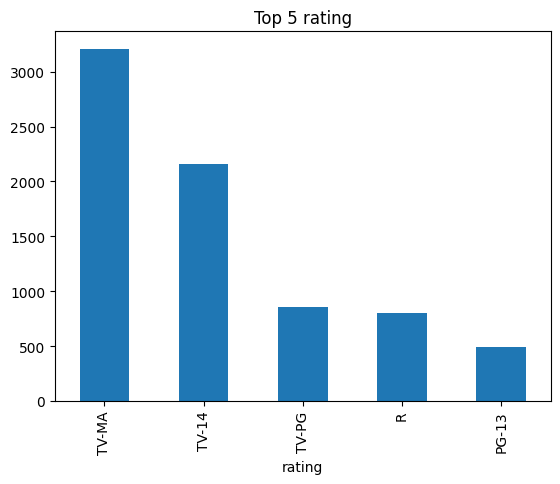

In [ ]:
import matplotlib.pyplot as plt

def plot_top_categories(column, n=5):
    df[column].value_counts().head(n).plot(kind='bar')
    plt.title(f'Top {n} {column}')
    plt.show()

plot_top_categories('rating')